In [9]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches
from scipy.integrate import simpson  
from joblib import Parallel, delayed
import matplotlib.cm as cm
import matplotlib.colors as colors
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import pandas as pd

In [10]:
#function
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)


    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
 
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r, Sigma_R, Sigma_L

def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, eta=1e-6):
    N = xshumu
    
    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

def Gr_DD_xuni(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, xshumu, E, Sigma_virtual_big, eta=1e-6):

    d_device = H_q_list[0].shape[0]  
    d_lead = H_l.shape[0]            
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    A_l = EI_lead - H_l
    gcl = gr_L_keni(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_lead - H_r
    gcr = gr_L_keni(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    A_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H_q_i = H_q_list[i]

        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == xshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < xshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T

    A_DD = np.block(A_DD)

    A_DD = A_DD - Sigma_virtual_big

    # 1. 将 numpy 密集数组转化为 CSC (Compressed Sparse Column) 稀疏矩阵格式
    A_DD_sparse = sp.csc_matrix(A_DD)
    
    # 2. 调用稀疏矩阵专用的求逆算法 (底层自动执行带状 LU 分解)
    # 因为格林函数 G^R 是致密的，所以求逆后我们将其转回普通的 numpy array
    G_DD_r = spla.inv(A_DD_sparse).toarray()
    
    return G_DD_r, Sigma_R, Sigma_L

def calc_T_eff_single(E_val, mats, xshumu, T_d_list, Sigma_virtual_big, eta=1e-6):
    # 提取当前通道的矩阵
    H_q_list = mats["H_q_list"]
    T_21 = mats["T_21"]
    H_l = mats["H_l"]
    T_l = mats["T_l"]
    H_r = mats["H_r"]
    T_r = mats["T_r"]
    T_LD = mats["T_LD"]
    T_RD = mats["T_RD"]

    G_all, Sigma_R, Sigma_L = Gr_DD_xuni(
        H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, 
        xshumu, E_val, Sigma_virtual_big, eta=eta
    )
    
    d_device = Sigma_L.shape[0]  
    M = xshumu * d_device        
    
    slices = []
    small_gammas = []
    
    gamma_L_small = 1j * (Sigma_L - Sigma_L.conj().T)
    slices.append((0, d_device))
    small_gammas.append(gamma_L_small)
    
    for i in range(xshumu):
        slices.append((d_device * i, d_device * i + d_device))
        small_gammas.append(T_d_list[i])
        
    gamma_R_small = 1j * (Sigma_R - Sigma_R.conj().T)
    slices.append((M - d_device, M))
    small_gammas.append(gamma_R_small)
    
    num_probes = len(slices) 
    
    # 计算多端透射矩阵 T_ij
    T_matrix = np.zeros((num_probes, num_probes), dtype=float)
    for i in range(num_probes):
        start_i, end_i = slices[i]
        gamma_i = small_gammas[i]
        for j in range(num_probes):
            if i == j: continue 
            start_j, end_j = slices[j]
            gamma_j = small_gammas[j]
            
            G_ij = G_all[start_i:end_i, start_j:end_j]
            Ga_ji = G_ij.conj().T
            T_matrix[i, j] = np.real(np.trace(gamma_i @ G_ij @ gamma_j @ Ga_ji))

    V_L = 1.0
    V_R = 0.0
    
    W = np.zeros((xshumu, xshumu), dtype=float)
    B_vec = np.zeros(xshumu, dtype=float)
    
    for p in range(1, xshumu + 1):  
        row = p - 1  
        W[row, row] = np.sum(T_matrix[p, :]) - T_matrix[p, p]
        
        for q in range(1, xshumu + 1):
            if p != q:
                col = q - 1
                W[row, col] = -T_matrix[p, q]
                
        B_vec[row] = T_matrix[p, 0] * V_L + T_matrix[p, num_probes - 1] * V_R

    V_virtual = np.linalg.solve(W, B_vec)

    # 计算有效电导 T_eff
    T_eff = T_matrix[0, num_probes - 1] * (V_L - V_R) 
    for v in range(1, xshumu + 1):
        T_eff += T_matrix[0, v] * (V_L - V_virtual[v - 1])
        
    return T_eff

def calc_G_total_at_E(E_val, matrix_dict, xshumu, T_d_list, Sigma_virtual_big, eta=1e-6):
    G_total_at_E = 0.0
    for dhs, mats in matrix_dict.items():
        G_single_channel = calc_T_eff_single(E_val, mats, xshumu, T_d_list, Sigma_virtual_big, eta)
        G_total_at_E += G_single_channel
        
    return G_total_at_E

def calc_G_total_at_E_1(E_val, matrix_dict, xshumu, eta):
    """
    计算给定单一能量点 E_val 下，所有 transverse modes 的总电导
    """
    G_total_at_E = 0.0  
    
    # 遍历字典中所有的横向模式
    for dhs, mats in matrix_dict.items():
        G_RL, Sigma_R, Sigma_L = Gr_DD_2(
            H_q_list=mats["H_q_list"],
            H_l=mats["H_l"],
            H_r=mats["H_r"],
            T_21=mats["T_21"],
            T_LD=mats["T_LD"],
            T_l=mats["T_l"],
            T_RD=mats["T_RD"],
            T_r=mats["T_r"],
            xshumu=xshumu, 
            E=E_val,
            eta=eta
        )
        
        # 计算左右电极的展宽矩阵
        zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
        zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)
        
        # 计算当前模式的透射率并累加
        G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
        G_total_at_E += np.real(G_complex)
        
    return G_total_at_E
    


In [11]:
#字典打包
def build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, xshumu):
    """
    根据锯齿形纳米管的结构参数，构建所有波矢 ky 通道下的哈密顿量与跃迁矩阵字典。
    """
    max_duihaoshu = int(2 * m / 3)
    matrix_dict = {}

    for duihaoshu in range(0, max_duihaoshu + 1):  
        ky = 2 * np.pi / 3 * 3 * duihaoshu / (b * 2 * m)
        
        H_q = H_onstie(mu_q, t)
        T_21 = H_hop(t, ky, b)

        H_q_list = [H_q for _ in range(xshumu)]
        
        H_l = H_onstie(mu_l, t)
        T_l = H_hop(t, ky, b).conj().T
        
        H_r = H_onstie(mu_r, t)
        T_r = H_hop(t, ky, b)
        
        T_LD = H_hop(t, ky, b) * 1
        T_RD = H_hop(t, ky, b).conj().T * 1

        matrix_dict[duihaoshu] = {
            "H_q_list": H_q_list,
            "T_21": T_21,
            "H_l": H_l,
            "T_l": T_l,
            "H_r": H_r,
            "T_r": T_r,
            "T_LD": T_LD,
            "T_RD": T_RD
        }
        
    return matrix_dict
#探针打包
def build_virtual_probes(xshumu, d_device=2, dephasing_strength=1e-6):
    """
    构建 Büttiker 虚拟探针的展宽矩阵列表和总退相干自能大矩阵。
    """
    M = xshumu * d_device  
    # 动态生成基础的探针展宽矩阵
    base_T_d = dephasing_strength * np.eye(d_device, dtype=complex)
    
    T_d_list = []
    xushuzineng_list = []

    for i in range(xshumu):
        current_T_d = base_T_d.copy()  
        T_d_list.append(current_T_d)
        xushuzineng_list.append(-1j * current_T_d / 2)

    # 手动分块组装大自能矩阵
    Sigma_virtual_big = np.zeros((M, M), dtype=complex)
    for i in range(xshumu):
        start_idx = d_device * i
        end_idx = d_device * i + d_device
        Sigma_virtual_big[start_idx:end_idx, start_idx:end_idx] = xushuzineng_list[i]
        
    return T_d_list, Sigma_virtual_big


In [12]:
#中间矩阵信息  锯齿形纳米管ky量子化，周长2b*m
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onstie(u, t):
    return -t*sx+(u)*s0

def H_hop(t,ky,b):
    return -2*t*np.cos(ky*b)*np.array([[0, 1], [0, 0]], complex)

mu_q=0
mu_r=-0.3*1
mu_l=-0.3*1
t=3

a=1
b=3**(0.5)/2*a

m=100
max_duihaoshu=int(2 * m / 3)
#print(max_duihaoshu)
xshumu=500 # 可变

matrix_dict = build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, xshumu)

T_d_list, Sigma_virtual_big = build_virtual_probes(xshumu, d_device=2, dephasing_strength=1e-6)



C:\Users\taoji\AppData\Local\Temp\ipykernel_29664\41599189.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
Calculating Lead bands: 100%|██████████| 67/67 [00:02<00:00, 24.44it/s]


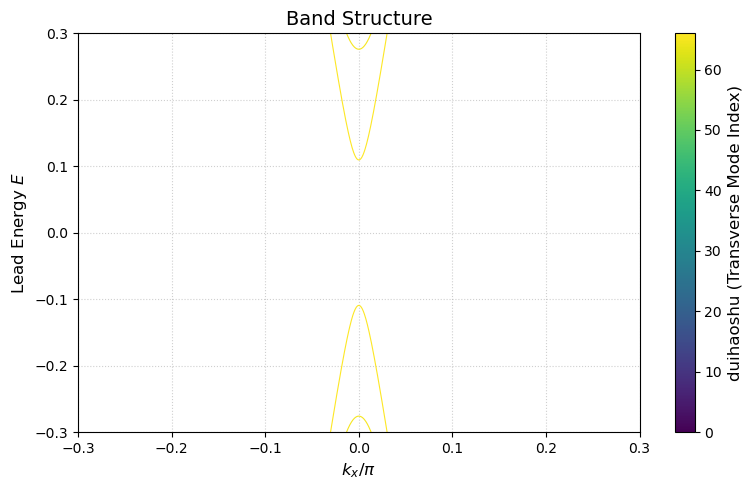

In [7]:
#ky(多个ky)画左边能带
ks1 = np.linspace(-1*np.pi, 1*np.pi, 5001)

def Hk(k, H, T):
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

plt.figure(figsize=(8, 5))

# ================= 设置色图 (Colormap) =================
cmap = cm.get_cmap('viridis')
# norm 将 duihaoshu 的范围 (0 到 max_duihaoshu) 映射到 0~1 的颜色空间
norm = colors.Normalize(vmin=0, vmax=max_duihaoshu)

# 遍历字典里的所有 duihaoshu 模式
for dhs, mats in tqdm(matrix_dict.items(), desc="Calculating Lead bands"):
    
    H_q = mats["H_q_list"][0] 
    T_21 = mats["T_21"]
    
    energies1 = []
    # 计算当前电极模式的能带
    for k in ks1:

        H_k = Hk(k, H_q, T_21)
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)
        
    energies1 = np.array(energies1)
    
    # 获取当前 duihaoshu 对应的颜色
    color = cmap(norm(dhs))
    
    # 画出当前电极模式的能带
    for i in range(energies1.shape[1]):
        # 使用 plot 画线，linewidth=0.8 既不会太细也不会互相粘连
        plt.plot(ks1/np.pi, energies1[:, i], color=color, linewidth=0.8)

# ================= 设置坐标轴和颜色条 =================
plt.xlabel(r'$k_x/\pi$', fontsize=12)
plt.ylabel('Lead Energy $E$', fontsize=12)
plt.title('Band Structure', fontsize=14) # 改了标题
plt.grid(True, linestyle=':', alpha=0.6)

# 添加右侧颜色条
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('duihaoshu (Transverse Mode Index)', fontsize=12)
plt.ylim(-0.3, 0.3)
plt.xlim(-0.3, 0.3)
plt.tight_layout()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_29664\2970802987.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
Calculating Lead bands: 100%|██████████| 67/67 [00:02<00:00, 24.51it/s]


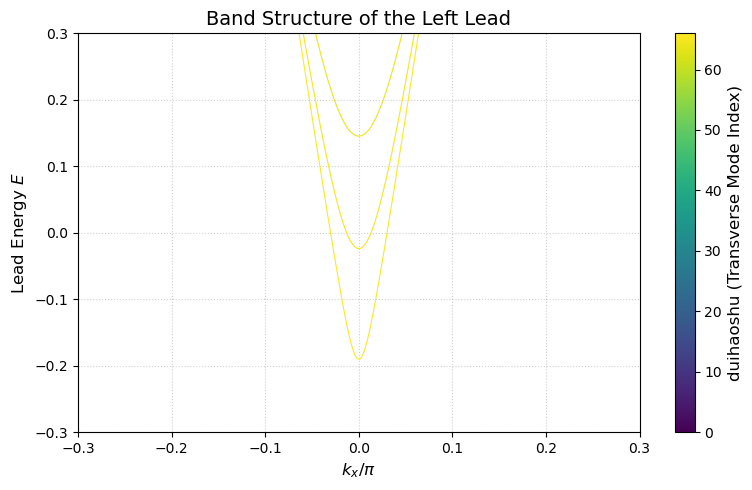

In [8]:
#ky(多个ky)画左边能带
ks1 = np.linspace(-1*np.pi, 1*np.pi, 5001)

def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

plt.figure(figsize=(8, 5)) # 保持宽比例，给 Colorbar 留位置

# ================= 设置色图 (Colormap) =================
cmap = cm.get_cmap('viridis')
# norm 将 duihaoshu 的范围 (0 到 max_duihaoshu) 映射到 0~1 的颜色空间
norm = colors.Normalize(vmin=0, vmax=max_duihaoshu)

# 遍历字典里的所有 duihaoshu 模式
for dhs, mats in tqdm(matrix_dict.items(), desc="Calculating Lead bands"):
    
    # ================= 核心修改 =================
    # 提取当前 duihaoshu 对应的【左电极】哈密顿量和跃迁矩阵
    H_l = mats["H_l"] 
    T_l = mats["T_l"]
    # ==========================================
    
    energies1 = []
    # 计算当前电极模式的能带
    for k in ks1:
        # 传入电极的 H_l 和 T_l
        H_k = Hk(k, H_l, T_l)
        evals1 = np.linalg.eigvalsh(H_k)
        energies1.append(evals1)
        
    energies1 = np.array(energies1)
    
    # 获取当前 duihaoshu 对应的颜色
    color = cmap(norm(dhs))
    
    # 画出当前电极模式的能带
    for i in range(energies1.shape[1]):
        # 使用 plot 画线，linewidth=0.8 既不会太细也不会互相粘连
        plt.plot(ks1/np.pi, energies1[:, i], color=color, linewidth=0.8)

# ================= 设置坐标轴和颜色条 =================
plt.xlabel(r'$k_x/\pi$', fontsize=12)
plt.ylabel('Lead Energy $E$', fontsize=12)
plt.title('Band Structure of the Left Lead', fontsize=14) # 改了标题
plt.grid(True, linestyle=':', alpha=0.6)

# 添加右侧颜色条
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('duihaoshu (Transverse Mode Index)', fontsize=12)
plt.ylim(-0.3, 0.3)
plt.xlim(-0.3, 0.3)
plt.tight_layout()
plt.show()

开始并行计算，总共 500 个能量点，启动 14 个线程...


Calculating Total Conductance: 100%|██████████| 500/500 [00:22<00:00, 22.12it/s]


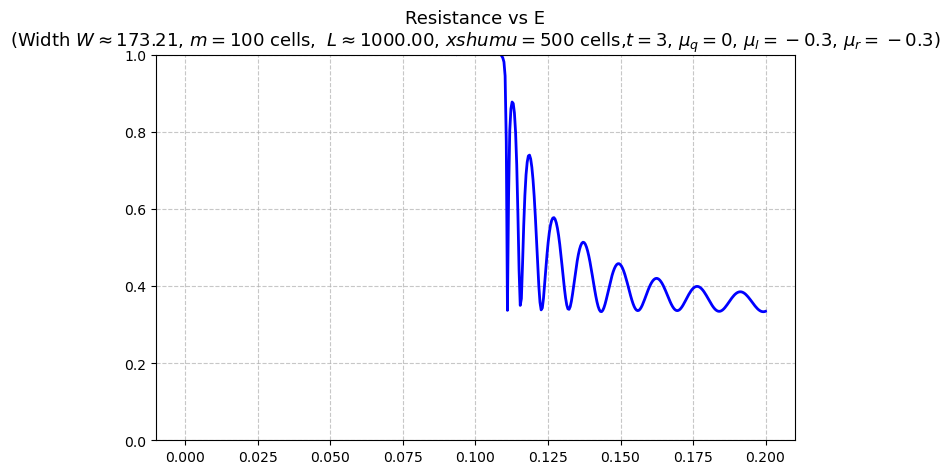

In [13]:
# G vs E xshumu定

E_vals = np.linspace(0, 0.2, 500)
eta = 1e-6

print(f"开始并行计算，总共 {len(E_vals)} 个能量点，启动 14 个线程...")

# 核心：使用 joblib 开启 14 个进程进行并行计算
# tqdm 用于在主进程中显示分配进度
G_total_list = Parallel(n_jobs=14)(
    delayed(calc_G_total_at_E_1)(E_val, matrix_dict, xshumu, eta) 
    for E_val in tqdm(E_vals, desc="Calculating Total Conductance")
)

# 将返回的列表转换为 numpy 数组以便画图
G_total_list = np.array(G_total_list)

# ================= 3. 画出物理图像 =================
plt.figure(figsize=(7, 5))

plt.plot(E_vals, 1/G_total_list, color='b', linewidth=2)

W_val = 2 * m * b
L_val= 2* xshumu* a
plt.title('Resistance vs E'+ '\n' + 
    rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells,  $L \approx {L_val:.2f}$, $xshumu={xshumu}$ cells,$t={t}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
    fontsize=13)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.ylim(0,1)

plt.show()

In [ ]:
    # G vs E xshumu定   虚拟探针
if 6==55:
    # ================= 4. 并行扫描能量 E 并画图 =================
    E_vals = np.linspace(0, 0.2, 3)
    eta = 1e-6

    print(f"启动 14 线程并行计算 G vs E (引入退相干效应)...")

    # 调用多线程与总电导求解函数
    G_total_list = Parallel(n_jobs=14)(
        delayed(calc_G_total_at_E)(E_val, matrix_dict, xshumu, T_d_list, Sigma_virtual_big, eta)
        for E_val in tqdm(E_vals, desc="Calculating Dephasing G")
    )

    G_total_list = np.array(G_total_list)

    # ================= 3. 画出物理图像 =================
    plt.figure(figsize=(7, 5))

    plt.plot(E_vals, 1/G_total_list, color='b', linewidth=2)

    W_val = 2 * m * b
    L_val= 2* xshumu* a
    plt.title('Resistance vs E'+ '\n' + 
        rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells,  $L \approx {L_val:.2f}$, $xshumu={xshumu}$ cells,$t={t}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
        fontsize=13)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    #plt.ylim(0,10)

    plt.show()

IndentationError: expected an indented block after 'if' statement on line 2 (3643540300.py, line 4)

In [ ]:
    # G vs E xshumu定   虚拟探针
if 6==3:
    matrix_dict = build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, xshumu)
    E_vals = np.linspace(0, 0.2, 50)
    eta = 1e-6

    print(f"启动 14 线程并行计算 G vs E (引入退相干效应)...")

    # ================= 3. 计算第一条线：dephasing_strength = 1e-6 =================
    T_d_list_1, Sigma_virtual_big_1 = build_virtual_probes(xshumu, d_device=2, dephasing_strength=1e-6)

    G_total_list_1 = Parallel(n_jobs=14)(
        delayed(calc_G_total_at_E)(E_val, matrix_dict, xshumu, T_d_list_1, Sigma_virtual_big_1, eta)
        for E_val in tqdm(E_vals, desc="Calculating Dephasing G (1e-6)")
    )
    G_total_list_1 = np.array(G_total_list_1)

    # ================= 4. 计算第二条线：dephasing_strength = 0.05 =================
    T_d_list_2, Sigma_virtual_big_2 = build_virtual_probes(xshumu, d_device=2, dephasing_strength=0.05)

    G_total_list_2 = Parallel(n_jobs=14)(
        delayed(calc_G_total_at_E)(E_val, matrix_dict, xshumu, T_d_list_2, Sigma_virtual_big_2, eta)
        for E_val in tqdm(E_vals, desc="Calculating Dephasing G (0.05)")
    )
    G_total_list_2 = np.array(G_total_list_2)

    # ================= 5. 画出物理图像 =================
    plt.figure(figsize=(7, 5))

    # 绘制两条曲线，并分别设置标签 (label) 和颜色
    plt.plot(E_vals, 1/G_total_list_1, color='b', linewidth=2, label=r'Dephasing strength = $10^{-6}$')
    plt.plot(E_vals, 1/G_total_list_2, color='r', linewidth=2, label=r'Dephasing strength = $0.05$')

    W_val = 2 * m * b
    L_val= 2* xshumu* a
    plt.title('Resistance vs E'+ '\n' + 
        rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells,  $L \approx {L_val:.2f}$, $xshumu={xshumu}$ cells,$t={t}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
        fontsize=13)

    # 显示图例
    plt.legend(fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    #plt.ylim(0,10)

    plt.show()

SyntaxError: 'break' outside loop (1202758060.py, line 3)

启动 14 线程并行计算 G vs E (当前 CPU 核心利用率优化为 100%)...

---> 开始计算: 纯相干输运 (Dephasing = 0)




Coherent G (0): 100%|██████████| 30/30 [00:01<00:00, 28.61it/s]



---> 开始计算: 耗散输运 (Dephasing = 0.05)




Dephasing G (0.05): 100%|██████████| 30/30 [03:53<00:00,  7.79s/it]



---> 开始计算: 耗散输运 (Dephasing = 0.1)


...


---> 开始计算: 耗散输运 (Dephasing = 0.2)




Dephasing G (0.2): 100%|██████████| 30/30 [02:30<00:00,  5.02s/it]



---> 开始计算: 耗散输运 (Dephasing = 0.5)




Dephasing G (0.5): 100%|██████████| 30/30 [02:27<00:00,  4.92s/it]



✅ 数据已成功保存至 Excel 文件: D:\结果\2026.6.11\Transport_Results.xlsx



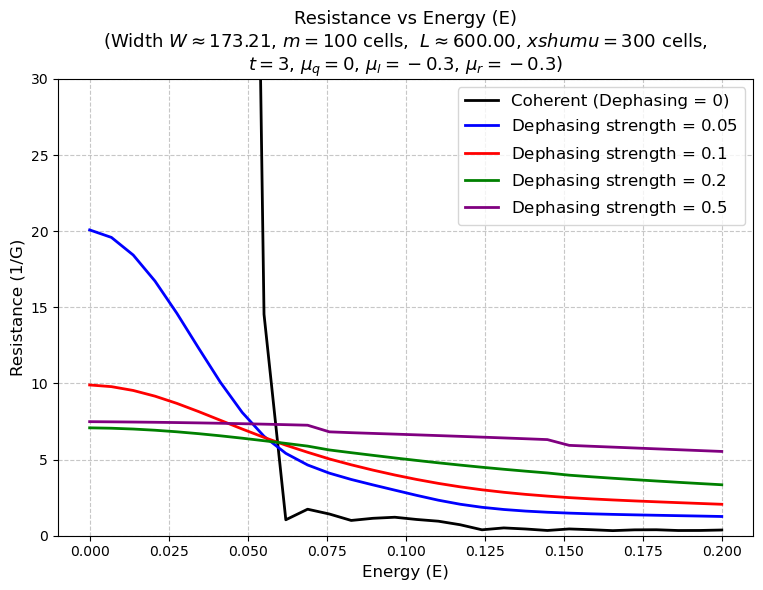

In [ ]:
# G vs E xshumu定   虚拟探针

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# (假设前面的 build_matrix_dict, calc_G_total_at_E_1, calc_G_total_at_E 等函数已定义)

# ================= 1. 初始化物理参数与哈密顿量 =================
matrix_dict = build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, xshumu)

E_vals = np.linspace(0, 0.2, 20)
eta = 1e-6

# ================= 2. 定义退相干强度列表 (可自由扩充) =================
# 包含 0 (纯相干)，以及其他的退相干强度
dephasing_strengths = [0, 0.05, 0.5]

# 用于存储不同强度下的 G_total_list，字典格式方便后续调用
results_dict = {}

print(f"启动 14 线程并行计算 G vs E (当前 CPU 核心利用率优化为 100%)...")

# ================= 3. 循环遍历不同的退相干强度 =================
for strength in dephasing_strengths:
    
    if strength == 0:
        print(f"\n---> 开始计算: 纯相干输运 (Dephasing = 0)")
        # 使用专为相干输运优化的极速算法 (Dyson / RGF)
        G_list = Parallel(n_jobs=14)(
            delayed(calc_G_total_at_E_1)(E_val, matrix_dict, xshumu, eta) 
            for E_val in tqdm(E_vals, desc="Coherent G (0)")
        )
        
    else:
        print(f"\n---> 开始计算: 耗散输运 (Dephasing = {strength})")
        # 1. 针对当前退相干强度，预先构建虚拟探针列表和大型自能矩阵
        T_d_list, Sigma_virtual_big = build_virtual_probes(xshumu, d_device=2, dephasing_strength=strength)
        
        # 2. 使用全矩阵求逆的多端 Büttiker 算法
        G_list = Parallel(n_jobs=14)(
            delayed(calc_G_total_at_E)(E_val, matrix_dict, xshumu, T_d_list, Sigma_virtual_big, eta)
            for E_val in tqdm(E_vals, desc=f"Dephasing G ({strength})")
        )
        
    # 保存当前 strength 对应的计算结果
    results_dict[strength] = np.array(G_list)


# ================= 数据导出：保存为 Excel 文件 =================
# 1. 确保目标文件夹存在
save_dir = r"D:\结果\2026.6.11"
os.makedirs(save_dir, exist_ok=True)

# 2. 将数据组装为字典，供 pandas 创建表格使用
data_to_save = {
    "Energy (E)": E_vals
}

# 遍历字典，把电导 G 和 电阻 1/G 分别存入不同的列
for strength in dephasing_strengths:
    G_arr = results_dict[strength]
    R_arr = 1 / G_arr
    data_to_save[f"G (Dephasing={strength})"] = G_arr
    data_to_save[f"Resistance (Dephasing={strength})"] = R_arr

# 3. 转换为 DataFrame 并导出到指定路径
df = pd.DataFrame(data_to_save)
excel_path = os.path.join(save_dir, rf"Transport_Results{dephasing_strengths}.xlsx")
df.to_excel(excel_path, index=False)
print(f"\n✅ 数据已成功保存至 Excel 文件: {excel_path}\n")
# ===============================================================


# ================= 4. 画出物理图像 =================
plt.figure(figsize=(8, 6))

# 定义一个颜色列表，如果你在 dephasing_strengths 里加了更多值，图表颜色也能自动适配
colors = ['black', 'blue', 'red', 'green', 'purple', 'orange']

for i, strength in enumerate(dephasing_strengths):
    G_arr = results_dict[strength]
    
    # 根据是否为 0 动态生成图例标签
    if strength == 0:
        label_str = r'Coherent (Dephasing = 0)'
        linestyle = '-'
    else:
        label_str = rf'Dephasing strength = ${strength}$'
        linestyle = '-'

    # 绘制 电阻 (1/G) 曲线
    plt.plot(E_vals, 1 / G_arr, color=colors[i % len(colors)], linewidth=2, 
             linestyle=linestyle, label=label_str)

# 标题参数动态格式化
W_val = 2 * m * b
L_val = 2 * xshumu * a
plt.title('Resistance vs Energy (E)\n' + 
    rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells,  $L \approx {L_val:.2f}$, $xshumu={xshumu}$ cells,' + '\n' +
    rf'$t={t}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
    fontsize=13)

plt.xlabel('Energy (E)', fontsize=12)
plt.ylabel('Resistance (1/G)', fontsize=12)

# 显示图例
plt.legend(fontsize=12, loc='best')

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# 如果有激烈的共振峰导致 y 轴比例失调，可以取消注释下面这行来限制观测范围
plt.ylim(0, 30)

plt.show()

正在读取数据: D:\结果\2026.6.11\Transport_Results 0  0.05 0.1 0.2 0.5.xlsx ...


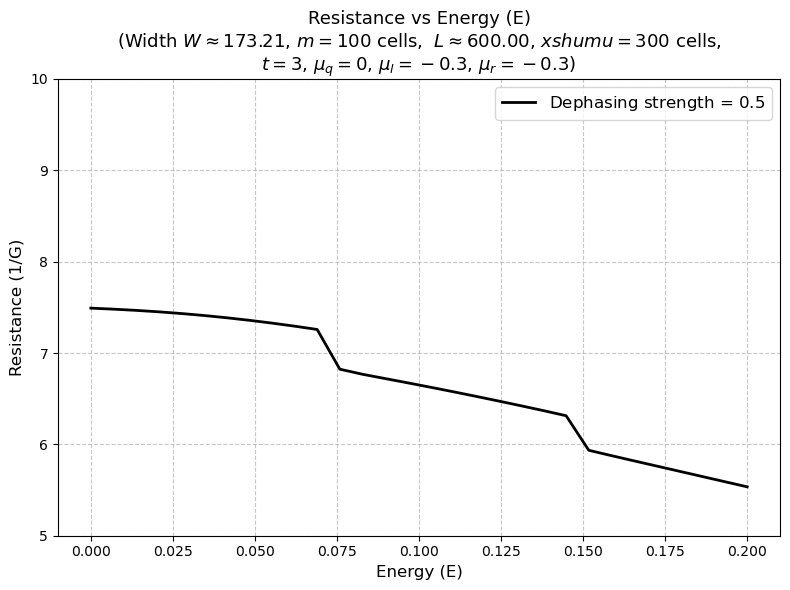

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ================= 0. 确认物理参数 =================
# 如果你在新的 Jupyter Cell 里运行，需要确保这些参数已被定义，
# 以便在标题 (title) 中正确显示。如果没有，请取消下方的注释：
# a = 1
# b = 3**(0.5)/2 * a
# m = 100
# xshumu = 300
# t = 3
# mu_q = 0
# mu_l = -0.3
# mu_r = -0.3

# ================= 1. 从 Excel 读取数据 =================
excel_path = r"D:\结果\2026.6.11\Transport_Results 0  0.05 0.1 0.2 0.5.xlsx"
print(f"正在读取数据: {excel_path} ...")
df = pd.read_excel(excel_path)

# 提取能量 (X 轴) 数据
E_vals = df["Energy (E)"].values

# 定义你需要读取和绘制的退相干强度
dephasing_strengths = [0.5]


# ================= 2. 画出物理图像 =================
plt.figure(figsize=(8, 6))

colors = ['black', 'blue', 'red', 'green', 'purple', 'orange']

for i, strength in enumerate(dephasing_strengths):
    # 根据我们之前保存的格式，动态生成列名
    col_name = f"Resistance (Dephasing={strength})"
    
    # 增加一个安全检查：确保这列数据确实在 Excel 中
    if col_name in df.columns:
        # 直接读取电阻数据 (不需要再除 1 了，因为存的就是 1/G)
        R_arr = df[col_name].values
        
        # 动态生成图例标签
        if strength == 0:
            label_str = r'Coherent (Dephasing = 0)'
            linestyle = '-'
        else:
            label_str = rf'Dephasing strength = ${strength}$'
            linestyle = '-'

        # 绘制曲线
        plt.plot(E_vals, R_arr, color=colors[i % len(colors)], linewidth=2, 
                 linestyle=linestyle, label=label_str)
    else:
        print(f"⚠️ 警告: Excel 中找不到 [{col_name}] 这一列数据，跳过绘制。")

# 标题参数动态格式化
W_val = 2 * m * b
L_val = 2 * xshumu * a
plt.title('Resistance vs Energy (E)\n' + 
    rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells,  $L \approx {L_val:.2f}$, $xshumu={xshumu}$ cells,' + '\n' +
    rf'$t={t}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
    fontsize=13)

plt.xlabel('Energy (E)', fontsize=12)
plt.ylabel('Resistance (1/G)', fontsize=12)

# 显示图例
plt.legend(fontsize=12, loc='best')

plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(5,10)
plt.tight_layout()

开始并行计算，扫描 99 个长度节点，启动 14 个线程...




Calculating Resistance vs Length: 100%|██████████| 99/99 [00:00<00:00, 998.79it/s]


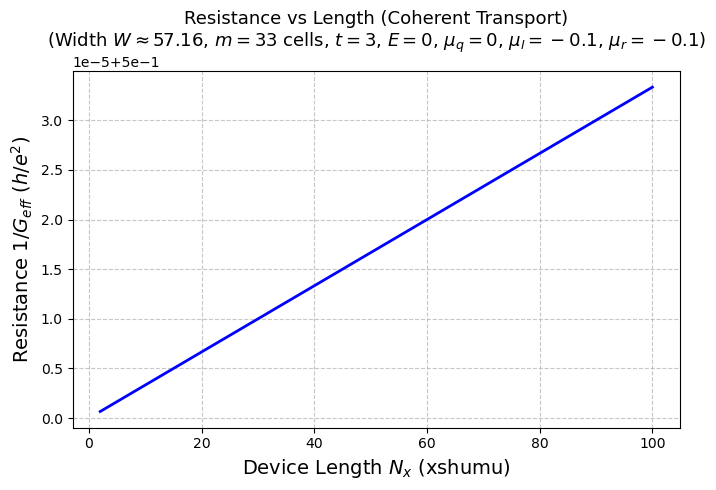

In [ ]:
# G vs E xshumu 不定
# ================= 1. 定义单次循环的封装函数 =================
def compute_R_for_length_coherent(xshumu_val, m, b, mu_q, mu_l, mu_r, t, E, eta):
    """
    计算特定长度 xshumu_val 下的相干总电阻（不含退相干探针）。
    """
    # 1. 动态构建该长度下的哈密顿量字典
    matrix_dict_1 = build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, xshumu_val)
    
    # 2. 计算有效电导
    gjvd = calc_G_total_at_E_1(E, matrix_dict_1, xshumu_val, eta)
    
    # 3. 返回电阻 (1/G)
    return 1 / gjvd

# ================= 2. 参数设置与并行计算 =================
xshumu_set = np.arange(2, 11)
E = 0
eta = 1e-6

print(f"开始并行计算，扫描 {len(xshumu_set)} 个长度节点，启动 14 个线程...")

# 核心：使用 Parallel 和 delayed 开启 14 线程并发执行
G_total_list = Parallel(n_jobs=14)(
    delayed(compute_R_for_length_coherent)(i, m, b, mu_q, mu_l, mu_r, t, E, eta) 
    for i in tqdm(xshumu_set, desc="Calculating Resistance vs Length")
)

# 将返回的列表转换为 numpy 数组以便画图
G_total_list = np.array(G_total_list)

# ================= 3. 画出物理图像 =================
plt.figure(figsize=(7, 5))

# 绘制电阻随长度变化的曲线
plt.plot(xshumu_set, G_total_list, color='b', linewidth=2)

plt.xlabel(r'Device Length $N_x$ (xshumu)', fontsize=14)
plt.ylabel(r'Resistance $1/G_{eff} \ (h/e^2)$', fontsize=14)

# 计算宽度 W，并添加到标题
W_val = 2 * m * b
# 注意：如果你这里计算的是纯相干输运，建议把标题的 with Büttiker Probes 删掉，以免日后自己看图时混淆
plt.title('Resistance vs Length (Coherent Transport)' + '\n' + 
    rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells, $t={t}$, $E={E}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
    fontsize=13)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
#plt.ylim(0, 5)

plt.show()

开始并行计算，扫描 49 个长度节点，启动 14 个线程...




Calculating Conductance vs Length: 100%|██████████| 49/49 [00:00<00:00, 2313.17it/s]


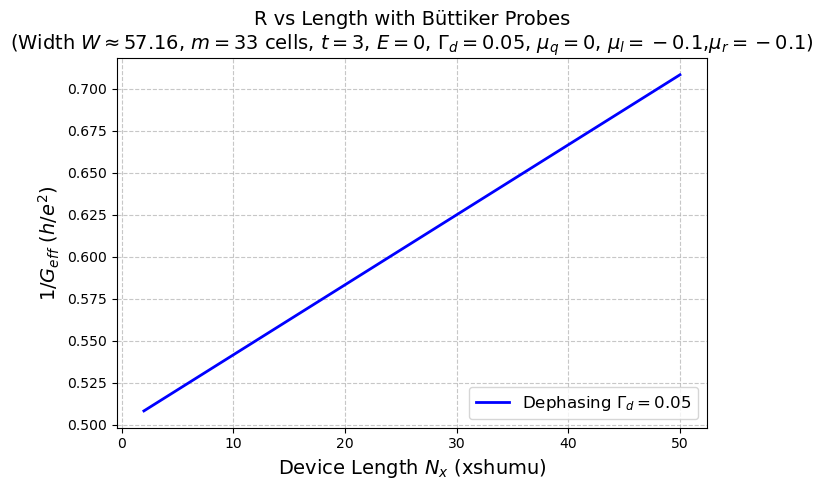

In [ ]:
# G vs E xshumu 不定 接上探针
def compute_G_for_length(xshumu_val, m, b, mu_q, mu_l, mu_r, t, E, eta):
    """
    计算特定长度 xshumu_val 下的含退相干总电导。
    这个函数将被 joblib 并行调用。
    """
    # 1. 构建该长度下的虚拟探针
    T_d_list_1, Sigma_virtual_big_1 = build_virtual_probes(xshumu_val, d_device=2, dephasing_strength=dephasing_strength_1)
    
    # 2. 构建该长度下的哈密顿量字典
    matrix_dict_1 = build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, xshumu_val)
    
    # 3. 计算包含 Büttiker 探针的总有效电导
    gjvd = calc_G_total_at_E(E, matrix_dict_1, xshumu_val, T_d_list_1, Sigma_virtual_big_1, eta=eta)
    
    return 1/gjvd

# ================= 2. 参数设置与并行计算 =================
xshumu_set = np.arange(2, 11)
E = 0
eta = 1e-6
dephasing_strength_1=0.05
print(f"开始并行计算，扫描 {len(xshumu_set)} 个长度节点，启动 14 个线程...")

G_total_list = Parallel(n_jobs=14)(
    delayed(compute_G_for_length)(i, m, b, mu_q, mu_l, mu_r, t, E, eta) 
    for i in tqdm(xshumu_set, desc="Calculating Conductance vs Length")
)

G_total_list = np.array(G_total_list)

# ================= 3. 画出物理图像 =================
plt.figure(figsize=(7, 5))

plt.plot(xshumu_set, G_total_list, color='b', linewidth=2, label=rf'Dephasing $\Gamma_d = {dephasing_strength_1}$')

plt.xlabel(r'Device Length $N_x$ (xshumu)', fontsize=14)
plt.ylabel(r'$1/G_{eff} \ (h/e^2)$', fontsize=14)

W_val = 2 * m * b
plt.title('R vs Length with Büttiker Probes'+ '\n' + 
    rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells, $t={t}$, $E={E}$, $\Gamma_d={dephasing_strength_1}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$,$\mu_r={mu_r}$)', 
    fontsize=14)

plt.grid(True, linestyle='--', alpha=0.7)
# 显示图例
plt.legend(loc='lower right', fontsize=12) 
plt.tight_layout()
#plt.ylim(0,5)

plt.show()

In [ ]:
# G vs E xshumu 不定 接上探针
# 【修改点】：增加 deph_str 作为参数传入，防止多进程调用全局变量出错
def compute_G_for_length(xshumu_val, m, b, mu_q, mu_l, mu_r, t, E, eta, deph_str):
    """
    计算特定长度 xshumu_val 下的含退相干总电导。
    这个函数将被 joblib 并行调用。
    """
    # 1. 构建该长度下的虚拟探针 (使用传入的 deph_str)
    T_d_list_1, Sigma_virtual_big_1 = build_virtual_probes(xshumu_val, d_device=2, dephasing_strength=deph_str)
    
    # 2. 构建该长度下的哈密顿量字典
    matrix_dict_1 = build_matrix_dict(m, b, mu_q, mu_l, mu_r, t, xshumu_val)
    
    # 3. 计算包含 Büttiker 探针的总有效电导
    gjvd = calc_G_total_at_E(E, matrix_dict_1, xshumu_val, T_d_list_1, Sigma_virtual_big_1, eta=eta)
    
    return 1 / gjvd

# ================= 2. 参数设置与并行计算 =================
xshumu_set = np.arange(2, 11)
E = 0
eta = 1e-6

# 【修改点】：定义需要扫描的失相强度列表
dephasing_strengths = [0.05]

# 准备画图的画布 (移到循环外面，这样四条线才会画在同一张图上)
plt.figure(figsize=(8, 6))

W_val = 2 * m * b

# 外层循环：遍历不同的失相强度
for deph_str in dephasing_strengths:
    print(f"\n开始并行计算，当前失相强度 Γ_d = {deph_str}，启动 14 个线程...")
    
    # 核心：使用 Parallel 和 delayed 并发执行封装好的函数
    G_total_list = Parallel(n_jobs=14)(
        delayed(compute_G_for_length)(i, m, b, mu_q, mu_l, mu_r, t, E, eta, deph_str) 
        for i in tqdm(xshumu_set, desc=f"Calculating (Γ_d={deph_str})")
    )
    
    G_total_list = np.array(G_total_list)
    
    # 为了图例好看，把 1e-6 写成科学计数法
    if deph_str == 1e-6:
        label_text = r'Dephasing $\Gamma_d = 10^{-6}$ (Ballistic)'
    else:
        label_text = rf'Dephasing $\Gamma_d = {deph_str}$'

    # 【修改点】：去掉 color='b'，让 matplotlib 自动分配不同颜色
    plt.plot(xshumu_set, G_total_list, linewidth=2, label=label_text)

# ================= 3. 画出物理图像及格式美化 =================
plt.xlabel(r'Device Length $N_x$ (x cell number)', fontsize=14)
# 修正了量纲单位：电导的倒数是电阻，单位应为 h/e^2
plt.ylabel(r'Resistance $1/G_{eff} \ (h/e^2)$', fontsize=14) 

# 修复了标题中 t= 后面缺失变量的小 typo
plt.title('Resistance vs Length with Büttiker Probes'+ '\n' + 
    rf'(Width $W \approx {W_val:.2f}$, $m={m}$ cells, $t={t}$, $E={E}$, $\mu_q={mu_q}$, $\mu_l={mu_l}$, $\mu_r={mu_r}$)', 
    fontsize=13)

plt.grid(True, linestyle='--', alpha=0.7)

# 显示图例 (因为电阻随长度增加而上升，图例放左上角 upper left 不容易遮挡数据线)
plt.legend(loc='upper left', fontsize=12) 
plt.tight_layout()

plt.show()


开始并行计算，当前失相强度 Γ_d = 0.05，启动 14 个线程...






















Calculating (Γ_d=0.05): 100%|██████████| 199/199 [00:57<00:00,  3.43it/s]


KeyboardInterrupt: 

<Figure size 800x600 with 0 Axes>